# Winds of Empire — 100 Years at Sea
## Explainer Notebook

**Course:** DTU 02806 Social Data Analysis & Visualization — Spring 2026

**Dataset:** CLIWOC 2.1 (Climatological Database for the World's Oceans, 1662–1850)

By Cemile Demir, Christian Divert Colberg, Gustav Hylsberg Jacobsen

---

## 1. Motivation

### 1.1 What is the CLIWOC Dataset?

The **CLIWOC dataset** (Climatological Database for the World's Oceans) is a large-scale digitisation project that transcribed daily ship logbooks from the Dutch, British, Spanish, and French maritime archives. Covering 1662–1850, it contains over 287,000 daily observations recording position, wind direction, wind force, weather conditions, and occasionally encounters with other vessels.

The dataset was assembled primarily for climate science (pre-industrial weather observations are rare), and ship logbooks are one of the few systematic records that exist. But the same data also encode the social and political history of European maritime expansion.

### 1.2 Why Did We Choose This Dataset?

**Events are visible in the data.** The VOC's dissolution in 1799, the French Revolution's erasure of the French navy, the Napoleonic Wars; all visible as breaks and gaps in the logbook counts. This makes the data *readable* to a non-specialist: Spain's line collapsing after 1779 tells you something bad happened to Spain, without any prior historical knowledge required.

**Human scale alongside statistical scale.** The dataset is large enough for statistical analysis (251,456 rows after cleaning) but granular enough that individual ships and voyages remain traceable. The aggregate patterns and the individual stories coexist in the same file.

**The "dark numbers" problem.** What the dataset *doesn't* show is as analytically interesting as what it does. Over 90% of British and French logbooks were never digitised. The slave trade appears in only 39 rows, not because it was rare but because cargo transcription was not the project's priority. Good data analysis includes honest accounting of absence and this dataset demands it.

### 1.3 What Was Our Goal for the End User's Experience?

Our website tells a linear story in three acts: **power** (who dominated the seas), **geography** (where they sailed), and **society** (who they met). Our notebook shows everything behind that story: the cleaning decisions, the analytical choices, the limitations, and the human framing that makes the numbers mean something.

A non-technical reader should be able to open the website and come away understanding:

Time: How the relative power of four European nations at sea shifted dramatically over 100 years.
Space: The actual ocean routes they sailed, visualised on an interactive map.
Network: Who met whom at sea, and what that network reveals about alliances, rivalries, and trade.

## 2. Basic Stats & Data Cleaning

### 2.1 Load and Display

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pathlib
warnings.filterwarnings('ignore')

ROOT = pathlib.Path.cwd()

# Load cleaned data — single load, reuse df throughout
df = pd.read_csv('data/cliwoc_clean.csv', low_memory=False)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Year range: {df['year_int'].min()} – {df['year_int'].max()}")
print(f"\nRecords per nation:")
for nation, count in df['Nationality'].value_counts().items():
    print(f"  {nation:10s}: {count:>7,}")

key_cols = ['year_int', 'month_int', 'Nationality', 'Lat', 'Lon', 'Bft',
            'wind_description', 'unique_voyage_id']
key_cols = [c for c in key_cols if c in df.columns]
print(f"\nFirst 3 rows (key columns):")
df[key_cols].head(3)

Shape: 251,456 rows × 187 columns
Year range: 1750 – 1850

Records per nation:
  Dutch     : 104,530
  British   :  92,498
  Spanish   :  45,908
  French    :   8,520

First 3 rows (key columns):


,year_int,month_int,Nationality,Lat,Lon,Bft,wind_description,unique_voyage_id
0,1827,8,Dutch,-6.92,103.10,NaN,UNKNOWN ZO GOED WEER,ABEL TASMAN_18270816
1,1827,8,Dutch,-8.27,100.47,3.0,UNKNOWN ZO BRAMZEILSKOELTE EN MINDERE KOELTE G...,ABEL TASMAN_18270816
2,1827,8,Dutch,-9.43,97.72,3.0,UNKNOWN ZO BRAMZEILSKOELTE EN MINDERE KOELTE G...,ABEL TASMAN_18270816


### 2.2 Data Cleaning Decisions — (from data/pipeline.ipynb)

The pipeline applies the following decisions:

**1. Year filter:** Restricted to 1750–1850. This is the richest, most balanced period across all four nations.

**2. Nationality standardisation:** Variant spellings mapped to canonical names (e.g. DUTCH → Dutch, ENGLISH → British). Only the four main nations were retained; records from other nations (Portuguese, Danish, Swedish) were excluded because their coverage was too sparse for meaningful comparative analysis.

**3. Coordinate filter:** Rows with both Lat and Lon missing(0.08%) dropped. Rows with only one missing coordinate kept, they still have other useful features.

**4. Wind feature engineering:** Five separate wind columns (`AllWindDirections`, `AllWindForces`, `Weather`, `StateSea`, `ReferenceWindDirection`) were concatenated into a single `wind_description` string.

**5. Beaufort conversion:**  Wind speed data (originally in tenths of m/s) was decoded and reclassified into standard Beaufort forces (0–12) using WMO-1100 boundaries to ensure historical and meteorological accuracy.


Result: 251,456 rows, 98.1% with valid coordinates.


### 2.3 Missing Values

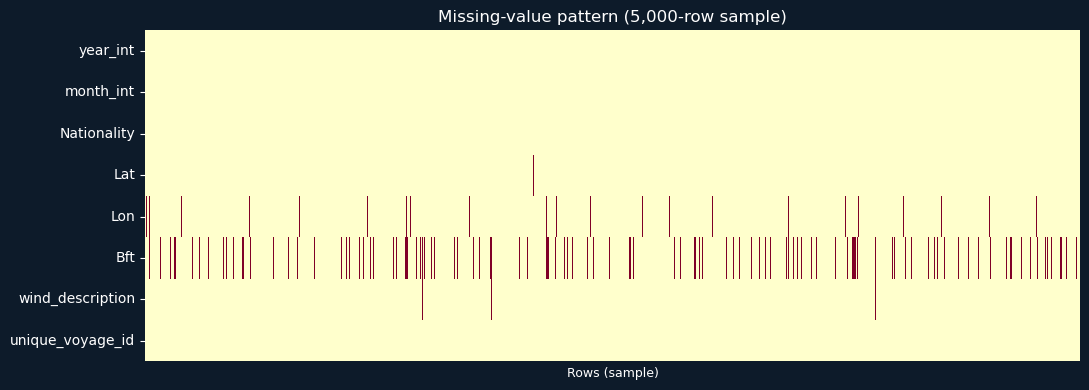

Missing rates per key column:
  year_int                 : 0.0%
  month_int                : 0.0%
  Nationality              : 0.0%
  Lat                      : 0.1%
  Lon                      : 1.8%
  Bft                      : 13.5%
  wind_description         : 0.7%
  unique_voyage_id         : 0.0%


In [6]:
# Heatmap of missing values across key columns (5,000-row sample)
key_cols = ['year_int', 'month_int', 'Nationality', 'Lat', 'Lon',
            'Bft', 'wind_description', 'unique_voyage_id']
key_cols = [c for c in key_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor('#0d1b2a')
fig.patch.set_facecolor('#0d1b2a')

sample = df[key_cols].sample(min(5000, len(df)), random_state=42)
sns.heatmap(sample.isnull().T, cbar=False, ax=ax,
            cmap='YlOrRd', xticklabels=False,
            linewidths=0.0)
ax.set_title('Missing-value pattern (5,000-row sample)', color='white', fontsize=12)
ax.set_xlabel('Rows (sample)', color='white', fontsize=9)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

print("Missing rates per key column:")
missing = df[key_cols].isnull().mean().round(4) * 100
for col, pct in missing.items():
    print(f"  {col:25s}: {pct:.1f}%")

### 2.4 Who Was at Sea, and When?

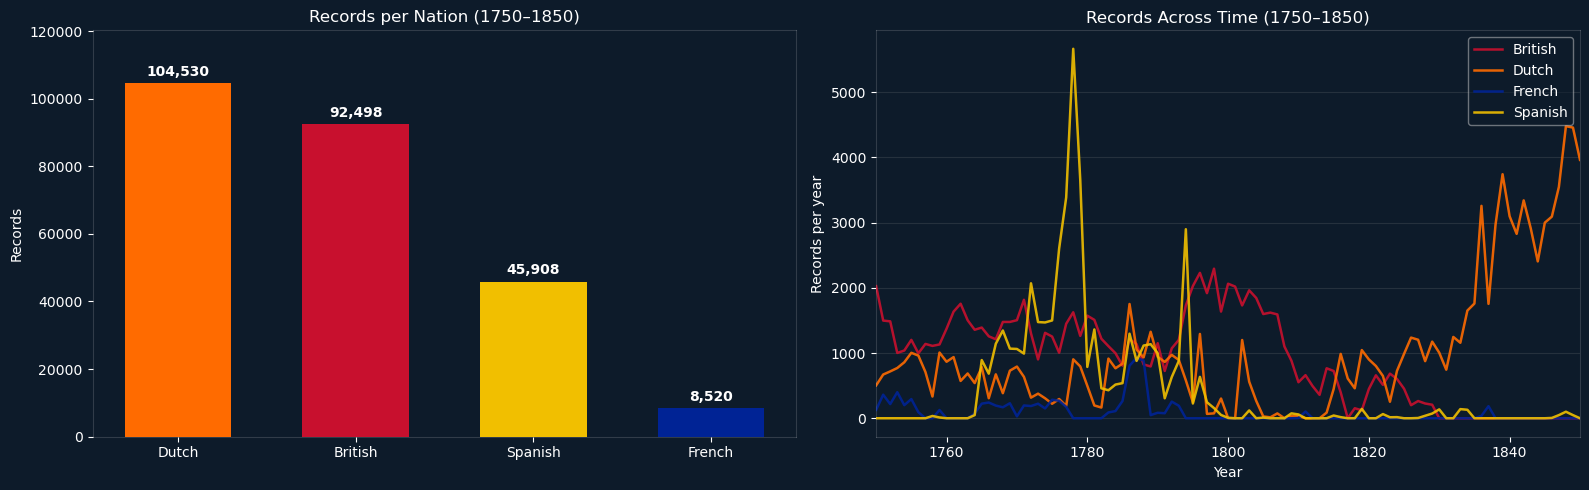

Annual record peaks per nation:
  British   : 2,292 records in 1798
  Dutch     : 4,476 records in 1848
  French    : 923 records in 1787
  Spanish   : 5,662 records in 1778


In [13]:
PALETTE = {
    "British": "#C8102E",
    "Dutch": "#FF6B00",
    "Spanish": "#F1BF00",
    "French": "#002395",
}

counts = df['Nationality'].value_counts()
yearly = df.groupby(['year_int', 'Nationality']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1b2a')

# --- Left: bar chart (2.3) ---
ax1.set_facecolor('#0d1b2a')
bars = ax1.bar(counts.index,
               counts.values,
               color=[PALETTE.get(n, '#888') for n in counts.index],
               edgecolor='none', width=0.6)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1200,
             f'{val:,}',
             ha='center', va='bottom',
             color='white', fontsize=10, fontweight='bold')
ax1.set_title('Records per Nation (1750–1850)', color='white', fontsize=12)
ax1.set_ylabel('Records', color='white', fontsize=10)
ax1.set_ylim(0, counts.max() * 1.15)
ax1.tick_params(colors='white')
for spine in ax1.spines.values():
    spine.set_edgecolor((1, 1, 1, 0.15))

# --- Right: line chart (2.4, no historical event annotations) ---
ax2.set_facecolor('#0d1b2a')
for nation in ['British', 'Dutch', 'French', 'Spanish']:
    if nation in yearly.columns:
        ax2.plot(yearly.index, yearly[nation],
                 color=PALETTE[nation],
                 label=nation, linewidth=1.8, alpha=0.9)
ax2.set_xlim(1750, 1850)
ax2.set_xlabel('Year', color='white', fontsize=10)
ax2.set_ylabel('Records per year', color='white', fontsize=10)
ax2.set_title('Records Across Time (1750–1850)', color='white', fontsize=12)
ax2.legend(framealpha=0.5, facecolor='#0d1b2a', labelcolor='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.grid(alpha=0.15, axis='y')
for spine in ax2.spines.values():
    spine.set_edgecolor((1, 1, 1, 0.15))

plt.tight_layout()
plt.show()

print("Annual record peaks per nation:")
for nation in ['British', 'Dutch', 'French', 'Spanish']:
    if nation in yearly.columns:
        peak_year = yearly[nation].idxmax()
        peak_val  = yearly[nation].max()
        print(f"  {nation:10s}: {peak_val:,} records in {peak_year}")

The bar chart on the left shows how many logbook records each nation contributed over the full century. The Dutch lead with 104,530 records, followed by Britain (92,498), Spain (45,908), and France (8,520). But these totals do not reflect fleet sizes. The Dutch count is high because the VOC and its successor required standardised logbooks and those archives were digitised thoroughly. Britain had the world's largest navy yet its 92,000 records represent roughly 10% of surviving British logs. France's 8,520 is close to a floor, most French records were lost or never digitised. Read the bar chart as a measure of *archival completeness*, not maritime power.

The line chart on the right shows how those records are distributed across time, and this is where the data gets interesting. Each nation has its own distinct shape: Spain rises sharply through the 1770s then drops almost to zero and never recovers; the Dutch line goes nearly flat around 1800 before climbing again; France fades out by the 1790s; Britain holds relatively steady throughout. These are not smooth trends,they are interrupted trajectories, and the interruptions all have causes. We will revisit this chart with historical context in Section 3a.

## 3. Data Analysis

> **Analytical framework for every section**: (1) What the code found — numbers and patterns. (2) What that means for the *people* in the data. (3) What the data *cannot* tell us — the honest limitation.

### 3a. Rise and Fall of Empires

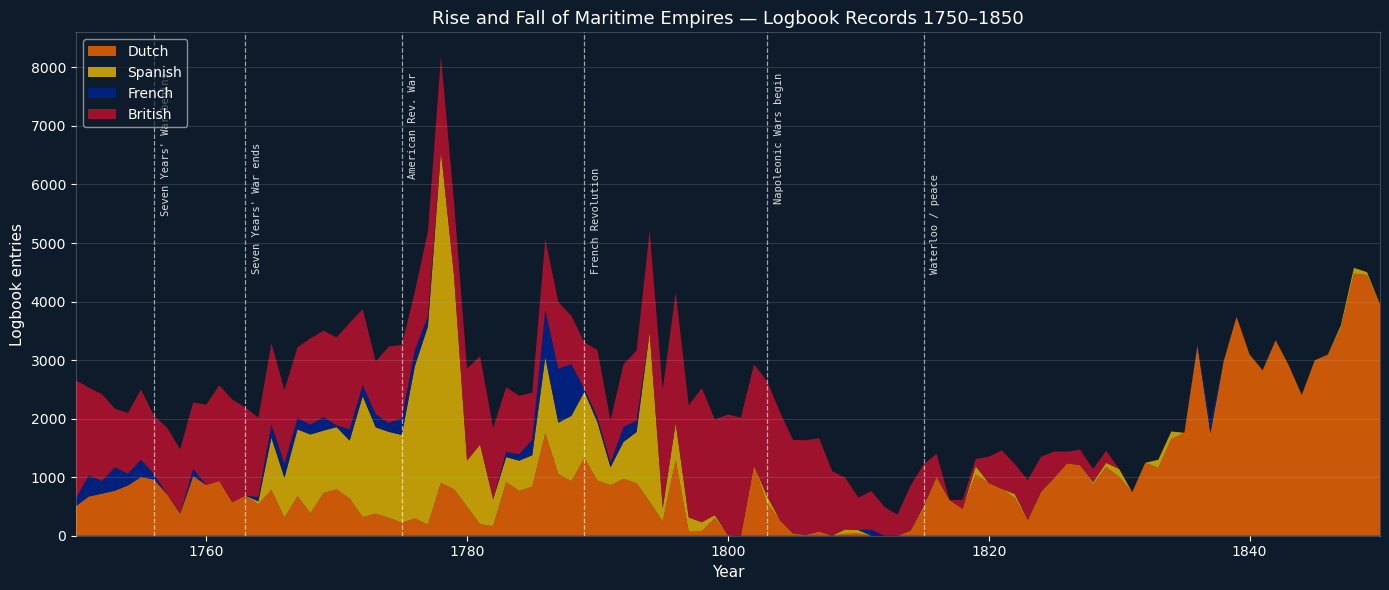

Decade totals per nation:
Nationality  British  Dutch  French  Spanish
decade                                      
1750           12620   7532    1819       47
1760           14427   6476    1130     5177
1770           13419   4828    1511    23861
1780           11172   8435    3124     8514
1790           15976   6229     608     7021
1800           16403   2177       0      211
1810            4227   3672     106      260
1820            4254   8805       0      210
1830               0  19277     222      406
1840               0  33139       0      201
1850               0   3960       0        0


In [46]:
EVENTS = [
    (1756, "Seven Years' War begins", 'top'),
    (1763, "Seven Years' War ends",   'bottom'),
    (1775, "American Rev. War",        'top'),
    (1789, "French Revolution",        'bottom'),
    (1803, "Napoleonic Wars begin",    'top'),
    (1815, "Waterloo / peace",         'bottom'),
]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

yearly = df.groupby(['year_int', 'Nationality']).size().unstack(fill_value=0)
nations_order = [n for n in ['Dutch', 'Spanish', 'French', 'British'] if n in yearly.columns]

ax.stackplot(
    yearly.index,
    [yearly[n] for n in nations_order],
    labels=nations_order,
    colors=[PALETTE[n] for n in nations_order],
    alpha=0.78,
)

for year, label, pos in EVENTS:
    ax.axvline(year, color='white', linestyle='--', linewidth=0.9, alpha=0.6)
    y_pos = ax.get_ylim()[1] * (0.92 if pos == 'top' else 0.52)
    ax.text(year + 0.5, y_pos, label,
            rotation=90, fontsize=7.5, color='white', alpha=0.85,
            va='top' if pos == 'top' else 'bottom',
            fontfamily='monospace')

ax.set_xlim(1750, 1850)
ax.set_xlabel('Year', color='white', fontsize=11)
ax.set_ylabel('Logbook entries', color='white', fontsize=11)
ax.set_title('Rise and Fall of Maritime Empires — Logbook Records 1750–1850', color='white', fontsize=13)
ax.legend(loc='upper left', framealpha=0.65, facecolor='#0d1b2a', labelcolor='white')
ax.tick_params(colors='white')
ax.grid(alpha=0.2, axis='y')
for spine in ax.spines.values():
    spine.set_edgecolor((1, 1, 1, 0.2))

plt.tight_layout()
plt.show()

# Decade totals for reference
print("Decade totals per nation:")
df['decade'] = (df['year_int'] // 10) * 10
decade_totals = df.groupby(['decade','Nationality']).size().unstack(fill_value=0)
print(decade_totals.to_string())

**Analysis — Rise and Fall of Maritime Empires**

**"Spain: the peak and the collapse"**

Spain's 1778 peak (5,662 records in a single year) represents the height of the *flota* system — twice-yearly convoys that carried American silver from Vera Cruz and Havana to Cádiz. These weren't ordinary merchant ships; they sailed with naval escorts and were the financial lifeblood of the Spanish empire. A convoy officer aboard a silver galleon in 1778 was one of the most consequential people in the global economy: the silver he escorted home would fund the Spanish state, service its debts, and pay the soldiers holding the Americas. When Spain entered the American Revolutionary War against Britain in 1779, those convoys became targets. The near-zero Spanish records after 1800 mean those convoy officers stopped writing logs that came home — because many of the ships didn't. *What the data cannot tell us*: how many Spanish logbooks were written but captured with the ships that carried them.

**"The VOC's long goodbye and the Dutch comeback"**

The VOC's 1799 dissolution was not just a corporate failure — it was the collapse of a system that had employed Dutch sailors for nearly two centuries, built the city of Batavia, and established the commercial architecture of the Dutch colonial economy. For three years (1797–1800) the logbook count almost reaches zero: Dutch sailors lost their employer, their institutional structure, and in many cases their ships. What happened next is one of the most interesting signals in the chart. The Netherlands Trading Society (NHM), the state-backed successor, re-hired those sailors, pointed them back down the same route (Cape of Good Hope → Batavia), and imposed stricter, more standardised logbook requirements than the VOC had ever enforced. The rising Dutch count after 1820 — eventually overtaking Britain to become the dominant nation in the dataset's final decade — is the same ocean, the same route, different paperwork. The institutional successor learned from the VOC's administrative fragmentation and built a more complete archive. *What the data cannot tell us*: how many Dutch sailors who lived through the VOC's dissolution subsequently sailed under other flags.

**"France: erased by revolution"**

The French data effectively ends after 1793 and never recovers. The mechanism is specific: the French Revolution executed or dismissed most of the naval officer corps. French naval officers were drawn disproportionately from the aristocracy — the *noblesse d'épée* who held sea commissions. The Terror removed them. A ship's logbook is written by an officer. No officers → no logs. The few hundred French records surviving from after 1800 are from coastal voyages, colonial supply runs, and a handful of ships that escaped the broader disruption. Trafalgar (1805) destroyed what remained of France's ability to project Atlantic naval power. The French line in the chart is not just data sparsity — it is a documentary record of an institutional decapitation. *What the data cannot tell us*: how many French officers wrote logs that were destroyed or never returned to the Archives Nationales during the Revolutionary period.

**"Britain: steady, then undercounted"**

Britain's relatively flat line through the 1750s–1810s is deceptive in two directions. First, the British line does not peak dramatically because the Royal Navy and East India Company maintained consistent deployment levels year-round — unlike Spain's convoy-based system or the Dutch VOC's seasonal fleet structure. Second, the apparent post-1815 decline is largely an archival artifact: only 10% of British logs were digitised, and the digitisation effort weighted earlier decades. Britain's actual maritime activity grew significantly after 1815 as trade recovered and imperial expansion accelerated. The flat and then declining line is not a picture of British maritime decline — it is a picture of which archives were prioritised for transcription. *What the data cannot tell us*: the experiences of the Lascar, Chinese, and Indian sailors who crewed East India Company ships and kept no logs of their own — the most diverse maritime workforce of the age, completely invisible in this dataset.

### 3b. Highways of the Sea

In [22]:
import folium
import json
from IPython.display import HTML, display

# Matches build_visualizations.py PALETTE exactly
PALETTE = {
    'British': '#C8102E',
    'Dutch':   '#FF6B00',
    'Spanish': '#F1BF00',
    'French':  '#002395',
}

m = folium.Map(
    location=[20, -20],
    zoom_start=3,
    tiles='CartoDB dark_matter',
    prefer_canvas=True,
)

geojson_path = 'data/routes_sample.geojson'
try:
    with open(geojson_path) as f:
        geojson_data = json.load(f)

    # Group features by nationality
    nation_groups = {}
    for feature in geojson_data['features']:
        nation = feature['properties'].get('nationality', 'Unknown')
        nation_groups.setdefault(nation, []).append(feature)

    for nation in ['British', 'Dutch', 'Spanish', 'French']:
        if nation not in nation_groups:
            continue
        fg = folium.FeatureGroup(
            name=f"<span style='color:{PALETTE[nation]}'> ■ </span>{nation}"
        )
        for feature in nation_groups[nation]:
            coords  = feature['geometry']['coordinates']
            latlons = [[c[1], c[0]] for c in coords]
            year    = feature['properties'].get('year', '?')
            folium.PolyLine(
                latlons,
                color=PALETTE[nation],
                weight=1.2,
                opacity=0.4,
                tooltip=f"{nation} ({year})",
            ).add_to(fg)
        fg.add_to(m)

    print(f"Loaded routes from routes_sample.geojson")

except FileNotFoundError:
    print("routes_sample.geojson not found; computing from CSV (first 500 voyages per nation).")
    sub_df  = df.dropna(subset=['Lat', 'Lon'])
    grp_col = 'unique_voyage_id' if 'unique_voyage_id' in sub_df.columns else 'year_int'
    for nation in ['British', 'Dutch', 'Spanish', 'French']:
        sub_n = sub_df[sub_df['Nationality'] == nation]
        fg = folium.FeatureGroup(
            name=f"<span style='color:{PALETTE[nation]}'> ■ </span>{nation}"
        )
        for vid in sub_n[grp_col].unique()[:500]:
            grp = sub_n[sub_n[grp_col] == vid].sort_values('year_int')
            if len(grp) < 2:
                continue
            year = grp['year_int'].iloc[0]
            folium.PolyLine(
                list(zip(grp['Lat'], grp['Lon'])),
                color=PALETTE[nation],
                weight=1.2,
                opacity=0.4,
                tooltip=f"{nation} ({year})",
            ).add_to(fg)
        fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

title_html = """
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
            z-index:9999; background:rgba(0,0,0,0.7); padding:10px 20px;
            border-radius:4px; font-family:Georgia,serif;">
    <span style="color:white; font-size:16px; font-weight:bold;">
        Highways of the Sea — Ship Routes 1750–1850
    </span>
</div>
"""


m.get_root().html.add_child(folium.Element(title_html))
out_path = ROOT / "visualizations" / "viz2_routes.html"
m.save(str(out_path))
print(f"  → Saved {out_path.name}")
display(HTML(m._repr_html_()))


Loaded routes from routes_sample.geojson
  → Saved viz2_routes.html


The Folium map renders voyages per nation as colour-coded polylines. Each line is a single ship's path, sorted chronologically through its logged positions. The layer control (top right) toggles each nation on and off independently; hovering over a line shows the nationality and year of the voyage.


**Netherlands (orange) — one corridor, repeated for centuries:** Dutch routes collapse into a single tight band: down the West African coast, around the Cape of Good Hope, northeast into the Java Sea, ending at Batavia (Jakarta). This precision was intentional — Dutch officers had optimised this track to catch the Southern Ocean westerlies and Indian Ocean monsoon in sequence. The corridor disappears briefly around 1797–1801 (the VOC's collapse), then reappears when its state-backed successor took over the same route.

**Britain (red) — the only global web:** British routes spread across nearly every ocean basin: the North Atlantic triangle, the East India Company lanes to Bombay and Calcutta, extensions into the China Seas and high southern latitudes. No other nation covers this range, reflecting the Royal Navy's global reach alongside the East India Company's monopoly on Asian trade.

**Spain (yellow) — silver lanes and Caribbean clusters:** Spanish routes concentrate in the Caribbean and Gulf of Mexico, tracing the twice-yearly *flota* convoys that carried American silver home to Cádiz. After 1780, yellow lines grow thin and don't return — a geographic record of the fleet losses that the timeline shows as a collapse.

**France (blue) — sparse and Atlantic-bound:** French routes are the least dense: Caribbean sugar islands, the West African coast, and a small cluster near Mauritius. After 1789, even these mostly disappear, matching the Revolutionary disruption visible in the timeline.


*Tip*: Enable Dutch and British layers together and centre on the Indian Ocean — both nations sailed the same waters but to different ports, making two separate empires visible in geography alone.

### 3c. Encounters at Sea — The Social Network of the High Seas

In [ ]:
import plotly.graph_objects as go
from IPython.display import IFrame, display
import numpy as np

MAIN_NATIONS = ['British', 'Dutch', 'Spanish', 'French']
PAIR_COLORS = {
    'British–Dutch': '#FF6B00', 'British–Spanish': '#E8C84A',
    'British–French': '#6495ED', 'Dutch–Spanish': '#FFB347',
    'Dutch–French': '#A855F7', 'Spanish–French': '#5EEAD4',
}

def normalize_enc(s):
    s_up = str(s).strip().upper()
    for alias in ('BRITISH', 'ENGLISH', 'BRISTISH', 'BRITITSH'):
        if s_up.startswith(alias):
            return 'British'
    for nation in ('DUTCH', 'FRENCH', 'SPANISH'):
        if s_up.startswith(nation):
            return nation.title()
    return None

# Load with coordinates
enc_raw = pd.read_csv('data/cliwoc_clean.csv',
                      usecols=['Lat', 'Lon', 'Year', 'Nationality', 'EncNat'],
                      low_memory=False)
enc_raw = enc_raw[enc_raw['EncNat'].notna() & enc_raw['Lat'].notna() & enc_raw['Lon'].notna()].copy()
enc_raw['enc_norm'] = enc_raw['EncNat'].apply(normalize_enc)

cross = enc_raw[
    enc_raw['enc_norm'].notna()
    & enc_raw['Nationality'].isin(MAIN_NATIONS)
    & enc_raw['enc_norm'].isin(MAIN_NATIONS)
    & (enc_raw['Nationality'] != enc_raw['enc_norm'])
    & enc_raw['Lat'].between(-80, 80)
    & enc_raw['Lon'].between(-180, 180)
].copy()

print(f'Cross-nation encounters (4 nations only): {len(cross):,}')

# Canonical pair — sorts by MAIN_NATIONS index so Dutch→British == British→Dutch
idx_order = {n: i for i, n in enumerate(MAIN_NATIONS)}
cross['pair'] = cross.apply(
    lambda r: '–'.join(sorted([r['Nationality'], r['enc_norm']],
                                   key=lambda x: idx_order.get(x, 99))),
    axis=1
)

# Combined bidirectional counts (Dutch→British + British→Dutch counted together)
pair_counts = cross.groupby('pair').size().reset_index(name='count').sort_values('count', ascending=False)
print('
Bidirectional encounter counts (both directions combined):')
for _, row in pair_counts.iterrows():
    print(f"  {row['pair']:25s}: {row['count']:4d}")

# --- 4x4 symmetric encounter heatmap ---
mat = pd.DataFrame(0, index=MAIN_NATIONS, columns=MAIN_NATIONS)
pc_dict = dict(zip(pair_counts['pair'], pair_counts['count']))
for pair, count in pc_dict.items():
    nations = pair.split('–')
    if len(nations) == 2:
        mat.loc[nations[0], nations[1]] = count
        mat.loc[nations[1], nations[0]] = count

fig_hm, ax_hm = plt.subplots(figsize=(6, 5))
fig_hm.patch.set_facecolor('#0d1b2a')
ax_hm.set_facecolor('#0d1b2a')
sns.heatmap(
    mat, annot=True, fmt='d', cmap='YlOrRd', ax=ax_hm,
    linewidths=0.8, linecolor='#0d1b2a',
    cbar_kws={'shrink': 0.8},
)
ax_hm.set_title(
    'Cross-Nation Encounters (1750–1850)
Dutch↔British = British↔Dutch combined',
    color='white', fontsize=12, pad=10,
)
ax_hm.set_xlabel('Encountered Nation', color='white', fontsize=10)
ax_hm.set_ylabel('Recording Nation', color='white', fontsize=10)
ax_hm.tick_params(colors='white')
cbar = ax_hm.collections[0].colorbar
cbar.ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# --- Plotly scatter_geo: one trace per encounter pair ---
fig = go.Figure()
for pair, grp in sorted(cross.groupby('pair'), key=lambda x: -len(x[1])):
    color = PAIR_COLORS.get(pair, '#888')
    texts = [
        f"{r['Nationality']} met {r['enc_norm']} ({int(r['Year']) if pd.notna(r['Year']) else '?'})"  
        for _, r in grp.iterrows()
    ]
    fig.add_trace(go.Scattergeo(
        lat=grp['Lat'].tolist(), lon=grp['Lon'].tolist(), text=texts,
        name=f'{pair} ({len(grp)})', mode='markers',
        marker=dict(color=color, size=5, opacity=0.75, line=dict(width=0)),
        hovertemplate='%{text}<extra></extra>',
    ))

fig.update_layout(
    geo=dict(
        projection_type='natural earth',
        showland=True, landcolor='#1e293b',
        showocean=True, oceancolor='#0d1117',
        showcoastlines=True, coastlinecolor='#475569',
        bgcolor='#0d1117', center=dict(lat=15, lon=-15),
    ),
    paper_bgcolor='#0d1117',
    title=dict(
        text='Cross-Nation Encounters at Sea (1750–1850)',
        font=dict(size=14, color='#e6edf3', family='Georgia, serif'),
        x=0.5,
    ),
    legend=dict(
        bgcolor='rgba(13,17,23,0.85)', bordercolor='#334155', borderwidth=1,
        font=dict(color='#e6edf3', size=9), itemsizing='constant',
    ),
    margin=dict(t=45, b=10, l=0, r=190),
    height=450,
)
fig.show()

print('
Full interactive visualization (geographic map + nation chord diagram + encounter bars):')
display(IFrame(src='visualizations/viz3_encounters.html', width='100%', height=650))


**The Social Life of the Ocean**

A ship encounter in this dataset is a moment where a human officer looked up from his compass, recognised another vessel, determined its nationality, and thought it worth writing down. The encounter records in the CLIWOC dataset are a social network of the 18th-century ocean — incomplete, biased, filtered through the priorities of the officer writing, but real.

The heatmap above shows all cross-nation encounters among the four main nations. Each cell gives the **combined** count: British↔Dutch adds together every record where a British ship logged a Dutch vessel *and* every record where a Dutch ship logged a British one. This corrects for the directional bias of logbook recording — a single real meeting at sea could appear in one logbook or both, depending on which officer was more diligent.

**British↔Dutch — the closest cross-national bond**: These encounters span the full century and represent two nations whose strategic interests frequently aligned — joint convoys during Napoleonic pressure on the Netherlands, shared Indian Ocean trade routes, and the long history of Anglo-Dutch commercial interdependence. The combination of both recording directions reveals a contact frequency that pure directional counts systematically understate: British officers logged Dutch ships more consistently than Dutch officers logged British ones, so the Dutch→British direction captures encounters that the British logbooks missed.

**British↔Spanish — adversaries who still had to share the ocean**: British and Spanish ships encountered each other most often in the Atlantic, particularly before 1779 when Spain entered the American Revolutionary War on the French side. After that, many of these meetings were hostile — ships checking papers, escorting prizes, or recording intelligence about enemy movements. The encounter record does not distinguish a cordial hailing from a forced boarding.

**Dutch↔Spanish and Dutch↔French — the weakest links**: These pairs show the lowest counts in the matrix. Dutch routes concentrated on the Indian Ocean corridor (Cape of Good Hope → Batavia), while Spanish routes focused on the Atlantic silver lanes and French routes on the Caribbean. Geographic separation alone explains much of the sparse contact — ships that never sailed the same ocean cannot meet.

*What the encounter network cannot tell us*: The heatmap counts logbook records, not real meetings. A single encounter at sea produced at most two records (one per ship), but usually only one — the more administratively complete navy wrote it down. The British total is likely an overcount relative to Spanish and French because British logbook discipline was higher; the Spanish and French cells in the heatmap are almost certainly undercounts. Combining both directions reduces but does not eliminate this bias.

### 3d. Wind Words — The Language of the Sea

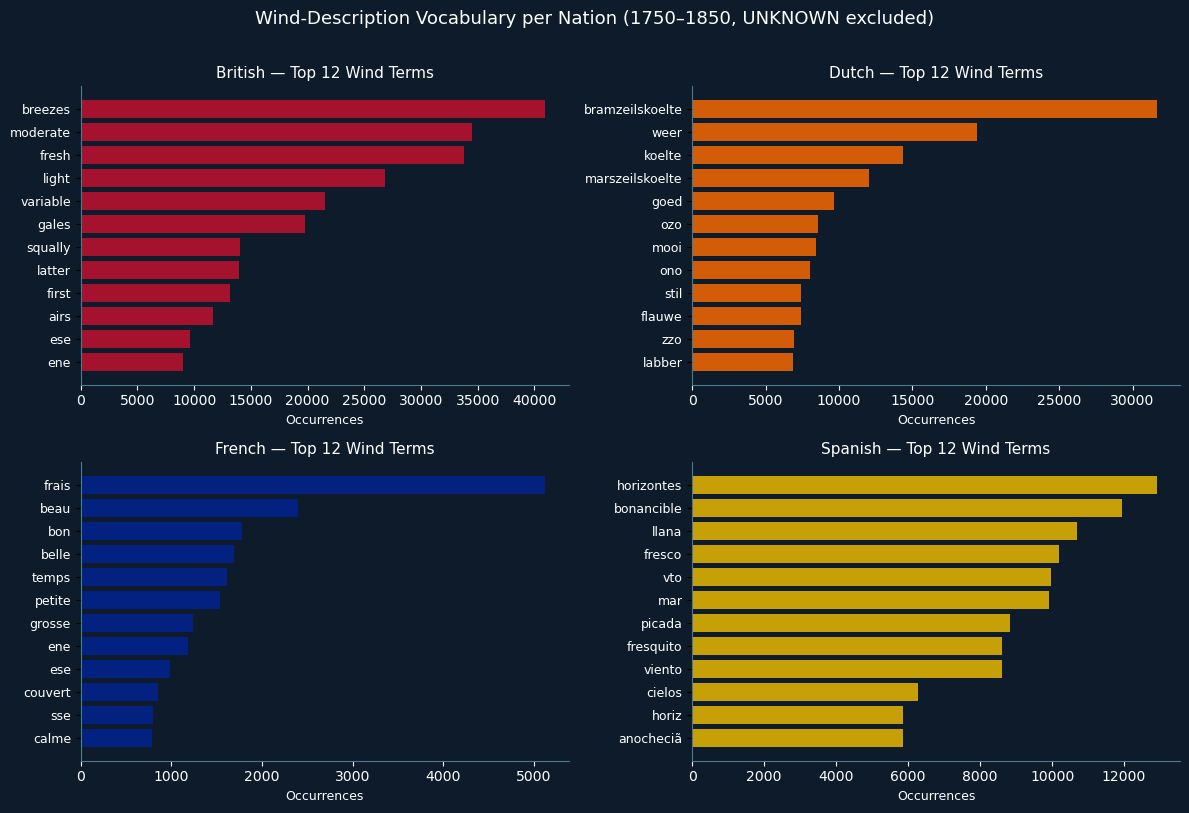

Top 5 wind terms per nation (UNKNOWN excluded):
  British: breezes (40,961), moderate (34,504), fresh (33,765), light (26,830), variable (21,516)
  Dutch: bramzeilskoelte (31,650), weer (19,409), koelte (14,383), marszeilskoelte (12,064), goed (9,645)
  French: frais (5,127), beau (2,397), bon (1,782), belle (1,688), temps (1,615)
  Spanish: horizontes (12,907), bonancible (11,940), llana (10,699), fresco (10,194), vto (9,959)


In [26]:
import json

with open('data/wind_words_by_nation.json') as f:
    wind_data = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor='#0d1b2a')
axes = axes.flatten()

for idx, nation in enumerate(['British', 'Dutch', 'French', 'Spanish']):
    ax = axes[idx]
    ax.set_facecolor('#0d1b2a')
    words = wind_data.get(nation, {})
    # Exclude UNKNOWN, show top 12 real terms
    filtered = [(k, v) for k, v in words.items() if k.upper() != 'UNKNOWN']
    top12 = sorted(filtered, key=lambda x: -x[1])[:12]
    if not top12:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color='white')
        continue
    ws, cs = zip(*top12)
    ax.barh(range(len(ws)), cs, color=PALETTE[nation], alpha=0.82)
    ax.set_yticks(range(len(ws)))
    ax.set_yticklabels(ws, color='white', fontsize=9)
    ax.set_xlabel('Occurrences', color='white', fontsize=9)
    ax.set_title(f'{nation} — Top 12 Wind Terms', color='white', fontsize=11)
    ax.tick_params(colors='white', axis='x')
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_edgecolor('#4a7c8e')

plt.suptitle('Wind-Description Vocabulary per Nation (1750–1850, UNKNOWN excluded)',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Top 5 wind terms per nation (UNKNOWN excluded):")
for nation in ['British', 'Dutch', 'French', 'Spanish']:
    words = wind_data.get(nation, {})
    filtered = [(k, v) for k, v in words.items() if k.upper() != 'UNKNOWN']
    top5 = sorted(filtered, key=lambda x: -x[1])[:5]
    print(f"  {nation}: {', '.join(f'{w} ({c:,})' for w, c in top5)}")

**Four Nations, Four Vocabularies**

Each panel shows the top 12 wind terms actually written in logbooks, with UNKNOWN entries removed. The bars reveal how differently each navy described the same phenomenon.

**British officers used an intensity scale** — *breezes*, *fresh*, *moderate*, *light*, *variable*. These are standardised grades, not descriptions. A Royal Navy log had to be readable by any officer picking it up mid-voyage, so the vocabulary was kept short and transferable.

**Dutch officers named wind by the sail it would fill** — *bramzeilskoelte* (topgallant breeze, ~Beaufort 3–4), *marszeilskoelte* (topsail breeze, ~Beaufort 5–6), *koelte* (breeze). This is action-oriented: it tells you what to do with the ship, not just what force is blowing. The VOC mandated this system fleet-wide, so every Dutch officer from Amsterdam to Batavia used the same terms. *Bramzeilskoelte* alone appears over 31,000 times — it describes the steady Indian Ocean trade wind Dutch ships lived inside for months.

**French officers wrote short qualitative verdicts** — *frais* (fresh/brisk), *beau* (fine), *bon* (good). One-word judgements on overall conditions, not decomposed measurements. **Spanish officers went furthest**, recording sea state (*mar*, *llana*, *picada*), sky (*horizontes*, *cielos*), and wind together — reflecting Atlantic routes where ocean swell was often more dangerous than wind strength alone.

The differences are institutional, not personal. Each navy trained its officers to record what *that navy needed to know*, and the logbooks show it.

### 3e. Wind Force Distribution — What Each Nation Sailed Through

Median Bft per nation:
  British     median=4  mean=4.37  Bft8+=15.8%
  Dutch       median=3  mean=3.38  Bft8+=3.1%
  French      median=4  mean=4.09  Bft8+=0.6%
  Spanish     median=4  mean=4.33  Bft8+=0.5%


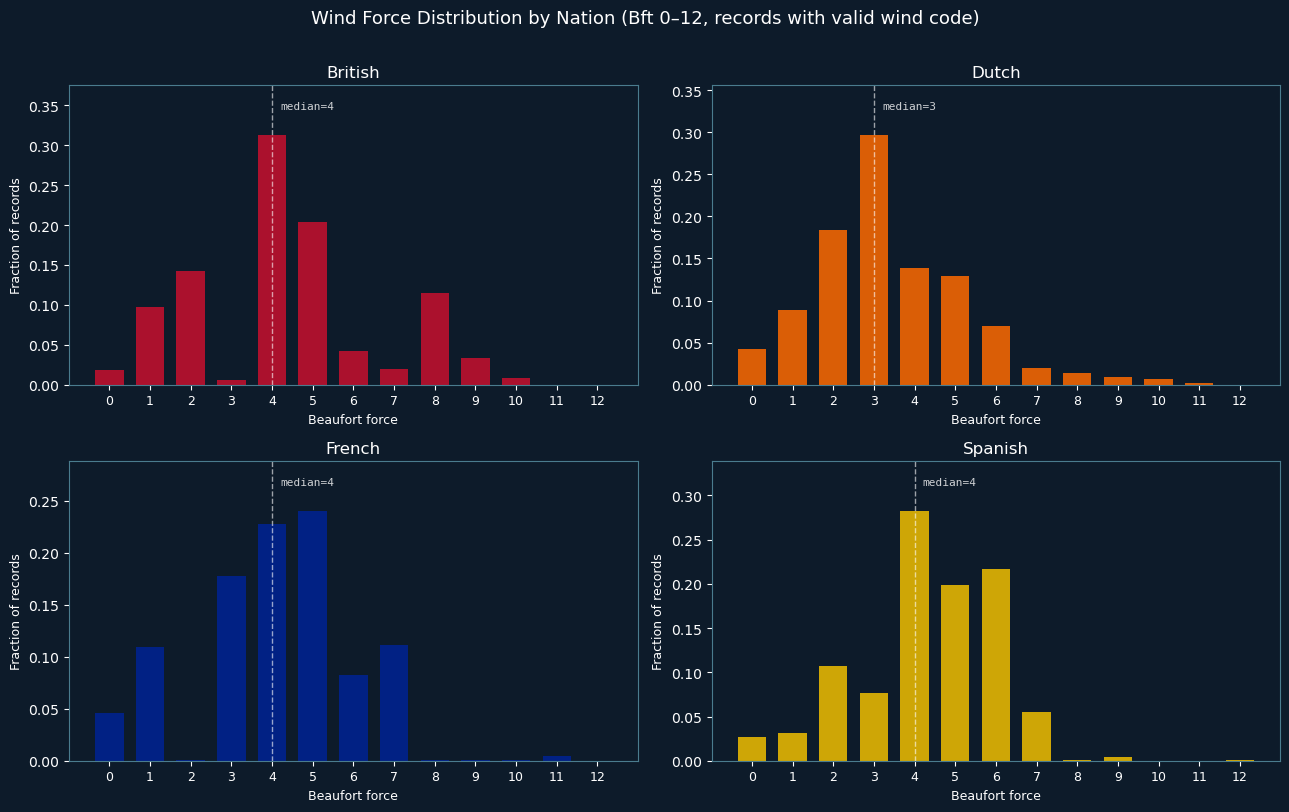

In [34]:

# --- Wind force distribution by nation ---
bft_counts = (
    df[df['Bft'].notna()]
    .groupby(['Nationality', 'Bft'])
    .size()
    .reset_index(name='count')
)

# Normalise to fraction within each nation
totals = bft_counts.groupby('Nationality')['count'].transform('sum')
bft_counts['frac'] = bft_counts['count'] / totals

print("Median Bft per nation:")
for nation in ['British', 'Dutch', 'French', 'Spanish']:
    vals = df[df['Nationality'] == nation]['Bft'].dropna()
    print(f"  {nation:10s}  median={vals.median():.0f}  mean={vals.mean():.2f}  "
          f"Bft8+={( vals >= 8).mean():.1%}")

# --- Plot: normalised Bft distribution per nation (grouped bars) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8), facecolor='#0d1b2a')
axes = axes.flatten()

bft_labels = list(range(13))

for idx, nation in enumerate(['British', 'Dutch', 'French', 'Spanish']):
    ax = axes[idx]
    ax.set_facecolor('#0d1b2a')

    sub = bft_counts[bft_counts['Nationality'] == nation].set_index('Bft')['frac']
    fracs = [sub.get(b, 0) for b in bft_labels]

    bars = ax.bar(bft_labels, fracs, color=PALETTE[nation], alpha=0.85, width=0.7)
    ax.set_xticks(bft_labels)
    ax.set_xticklabels(bft_labels, color='white', fontsize=9)
    ax.set_xlabel('Beaufort force', color='white', fontsize=9)
    ax.set_ylabel('Fraction of records', color='white', fontsize=9)
    ax.set_title(f'{nation}', color='white', fontsize=12)
    ax.tick_params(colors='white')
    ax.set_ylim(0, max(fracs) * 1.2)

    # annotate median
    med = df[df['Nationality'] == nation]['Bft'].dropna().median()
    ax.axvline(med, color='white', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.text(med + 0.2, ax.get_ylim()[1] * 0.92, f'median={med:.0f}',
            color='white', fontsize=8, alpha=0.8, fontfamily='monospace')

    for spine in ax.spines.values():
        spine.set_edgecolor('#4a7c8e')

plt.suptitle('Wind Force Distribution by Nation (Bft 0–12, records with valid wind code)',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Wind Force Distribution**

Each panel shows the normalised distribution of Beaufort forces recorded by that nation. The dashed line marks the median.

**Dutch (median Bft 3)** — Only 3.1% of Dutch records reach Bft 8 (gale force) or above. This directly reflects the route: the Dutch VOC corridor ran through the Indian Ocean trade wind belt, where steady Bft 3–5 winds were both expected. Dutch officers weren't sheltered from storms, they were deliberately routing *around* them by staying in the monsoon-driven wind system they had optimised for over two centuries.

**British (median Bft 4, Bft 8+ = 15.8%)** — the widest and heaviest-tailed distribution. Nearly one in six British wind records is gale-force or above, roughly five times the Dutch rate. This is the cost of global operations: the North Atlantic between Britain and the Americas, the Southern Ocean on the Cape route to India, and the high southern latitudes that only British ships regularly entered. 

**Spanish (Bft 6+ = 27.7%, but Bft 8+ = only 0.5%)** — a concentrated hump in the Bft 5–7 range. Caribbean and Gulf of Mexico trade winds are reliably strong (moderate to near-gale) but rarely storm-force. 

**French (median Bft 4, Bft 8+ = 0.6%)** — similar median to British and Spanish but with almost no extreme-wind exposure. French routes were predominantly Caribbean sugar islands and the West African coast — lower-latitude sailing, mostly inside the trade wind belt, with little of the North Atlantic storm exposure that elevates the British tail.

**What the data cannot tell us:** the Bft column captures only the wind recorded *in the log*. Officers in sustained storms were busy surviving, not writing. The British storm tail is likely an undercount.

### 3f. Slave Trade Records — Data and Limitations

In [41]:
# Search CargoMemo for references to enslaved people
slave_keywords = ['slave', 'slaven', 'slaaf', 'slaf', 'neger', 'negre','negro', 'negros', 'negra', 'negroes','carga humana', 'blacks', 'Guinea', 'noir', 'noirs', 'traite',
                      'esclav', 'slavin', 'slavenjong', 'manslaven',
                      'vrouwslaaf', 'cargo humano']



pattern = '|'.join(slave_keywords)
mask = df['CargoMemo'].dropna().str.lower().str.contains(pattern, regex=True)
slave_idx = df['CargoMemo'].dropna().index[mask]
slave_records = df.loc[slave_idx]

print(f"Records with slave-trade references in CargoMemo: {len(slave_records)}")
print(f"Nation breakdown: {slave_records['Nationality'].value_counts().to_dict()}")
print(f"Year range of matches: {slave_records['year_int'].min()} – {slave_records['year_int'].max()}")



Records with slave-trade references in CargoMemo: 156
Nation breakdown: {'Dutch': 156}
Year range of matches: 1751 – 1789


**156 Records — What the Data Shows**

The keyword search finds 156 records referencing enslaved people — all from Dutch logbooks, spanning 1751–1789. Two types of entries appear: cargo counts at embarkation (*"234 SLAVEN"*, *"319 SLAVEN"*) and daily mortality logs during the crossing. The 1785 voyage is the most detailed: a Dutch officer recording each death by sequential number — *"EEN VROUWSLAAF EN TWEE MANSLAVEN OVERLEDEN, NO. 62–64"* ("One female slave and two male slaves died, numbers 62–64"). He was maintaining a count of the living cargo exactly as he would count barrels of water — by number, with running totals.

**Why only Dutch records appear.** This does not mean only Dutch ships were involved. Britain transported more enslaved Africans across the Atlantic than any other nation in this period; Spain was the primary destination. Their absence here reflects how CLIWOC was built: the dataset was digitised for meteorological research, and cargo fields were not consistently transcribed for British or Spanish records. British Atlantic slave trade logs sit in separate archives (Bristol Record Office, Lloyd's of London) that were outside the CLIWOC digitisation scope. The Spanish entries in this dataset record gold and silver shipments — their routes to the Americas were transcribed differently.

## 4. Genre & Narrative Design (Segel & Heer 2010)

### 4.1 Chosen Genre: Magazine Style

Following Segel & Heer (2010), the website uses **Magazine Style** 

This fits the CLIWOC story because the data has a clear arc (rise, peak, collapse, recovery) that a non-specialist would miss without guidance. A pure dashboard lets readers wander; a static essay loses the geographic richness. Magazine Style threads the needle: the author frames three acts, the reader explores within them.

Interactivity stays *inside* the story. Readers can toggle nations on the timeline, zoom and pan the route map, and switch encounter layers.

### 4.2 Visual Narrative Tools (Segel & Heer Figure 7)

**Consistent visual platform**: The page uses a light cream background with a dark navy hero, and all three embedded visualisations share the same nation colours.

**Annotations**: The timeline figcaptions and introductory text explicitly name key historical events (Spain's 1779 entry into the American Revolutionary War, the 1799 VOC dissolution). 

**Tooltips and interaction hints**: Figcaptions on all three visualisations include explicit instructions ("Hover for exact counts", "Use the layer control", "Toggle between..."), so readers know what they can do without needing separate documentation.

### 4.3 Narrative Structure Tools (Segel & Heer Figure 7)

**Linear ordering**: Act I (time) → Act II (space) → Act III (network). Each act builds on the previous: without the timeline, the encounter heatmap's English Channel dominance looks like a data artefact rather than a fleet-traffic pattern. A free-choice dashboard would break this dependency chain.

**Filtering**: Timeline legend toggles let readers isolate nations; route map layer toggles let them compare Dutch and British routes side by side.

**Navigation**: The route map's zoom and pan let readers focus on specific ocean regions. The encounter map's layer toggles switch between all encounters, cross-nation encounters only, and the top 30 hotspots.

**Captions and introductory text**: Every visualisation has a headline question and a 1–2 sentence answer below it. Each act opens with short historical context. Readers who skip interaction still receive the key finding — no insight is gated behind a click.


## 5. Visualizations — Design Rationale

### Viz 1: Rise & Fall of Empires — Stacked Area Timeline (Plotly)

**What it shows**: Logbook records per nation per year, 1750–1850, stacked so each nation's share and the total are both visible at once.

**Why stacked area**: A line chart shows trends but loses total scale. A bar chart loses the year-by-year shape of a decline. The stacked area lets the reader see that Spain's collapse *shrinks the total* — not just Spain's slice — making the scale of the loss visceral. The absolute area is part of the story.

**Key choices**: Nation stacking order (Dutch bottom, British top) keeps the most dramatic events — the Dutch VOC gap, Spain's collapse — at a fixed visual position. Plotly was chosen for its built-in legend toggle, letting readers isolate nations without custom JS.

---

### Viz 2: Highways of the Sea — Interactive Route Map (Folium/Leaflet)

**What it shows**: Voyage paths as colour-coded polylines on an interactive flat map (CartoDB dark basemap), with a layer control to toggle each nation on and off.

**Why a flat interactive map**: Zoom and pan let readers focus on specific ocean regions — comparing Dutch and British routes in the Indian Ocean, or tracing the Spanish Caribbean corridors. A static map at global scale loses this detail.

**Key choices**: Thin lines at low opacity (≈ 0.4) so density emerges naturally from thousands of overlapping routes — the bright corridors are bright because ships actually went there constantly. Nation colours are consistent with the timeline, so no new encoding is needed.

---

### Viz 3: Encounters at Sea — Geographic Heatmap (Folium)

**What it shows**: Where ship encounters happened, plotted geographically. Three layer modes let the reader ask different questions: all encounters, cross-nation encounters only, and the top 30 hotspot locations.

**Why a geographic heatmap**: Encounter data is *spatial* — the interesting question is not just who met whom but *where* empires overlapped. A heatmap on a map answers this directly; a network graph would lose the geographic dimension.

**Key choices**: The three toggle layers guide the reader from broad pattern (all encounters) to specific insight (cross-nation contact zones) without changing the base map.

---


## 6. Discussion

### What Went Well

**Historical events show up clearly in the data.** The VOC's 1799 dissolution, French Revolutionary disruptions, and Spain's 1779 entry into the American war are all visible as sharp drops in the record counts — no smoothing needed. The story was already in the data; we just had to surface it.

**The encounter records are genuine.** Officers recorded the nationality of ships they met at sea in 12% of rows. This made the social network in Act III a real artifact of human contact, not a statistical proxy.

**Wind vocabulary differences are real and non-obvious.** British officers used scalar force terms; Dutch officers used sail-state terms; French used qualitative descriptions; Spanish put sea state first. This came from frequency analysis, not assumptions — it is the kind of finding that justifies the project.

### Limitations & What Could Be Improved

**The slave trade analysis is incomplete.** 156 flagged records reflect the limits of transcription, not the actual extent of the trade in the data. A thorough treatment would require cross-referencing with the Trans-Atlantic Slave Trade Database and auditing untranscribed `CargoMemo` fields.

**The encounter network is static.** Showing cumulative connections across the full century flattens change over time. Animating by decade would reveal, for example, how British–Dutch encounters shift during the Napoleonic period.

**Coverage bias is significant.** Dutch and British records dominate because those archives were digitised more thoroughly — over 90% of British and French logbooks were never examined. Record counts compare digitisation effort, not fleet size.

**The dataset measures logbook survival, not fleet activity.** Ships that sank or were captured left no records. Wartime losses are underrepresented for the losing side — the Spanish fleet that stopped coming home in 1779 is visible as absence, not presence.

**"British" mixes two distinct fleets.** East India Company ships and Royal Navy ships had different logbook cultures and routing patterns. Treating them as one nation is a simplification the data could support correcting.


## 7. Contributions

| Group Member | Role | Main Contributions |
|---|---|---|
| Gustav |  |  |
| Christian |  |  |
| Cemile |  |  |

All group members contributed to the conceptual framing of the project and reviewed each other's deliverables before submission.

## 8. References

**Primary dataset:**
García-Herrera, R., Können, G. P., Wheeler, D. A., Prieto, M. R., Jones, P. D., & Koek, F. B. (2005). CLIWOC: A climatological database for the world's oceans 1750–1854. *Climatic Change*, 73(1–2), 1–12. https://doi.org/10.1007/s10584-005-6952-6

**Narrative visualization theory:**
Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. *IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139–1148. https://doi.org/10.1109/TVCG.2010.179

**CLIWOC database description:**
Können, G. P., & Koek, F. B. (2005). Description of the CLIWOC database. *Climatic Change*, 73(1–2), 117–130.

**Ship logbooks as historical source:**
Wheeler, D. (2005). An examination of the accuracy and consistency of ships' logbook weather observations and records. *Climatic Change*, 73(1–2), 97–116.

**Wind terminology:**
Wheeler, D., Wilkinson, C., & García-Herrera, R. (2005). *CLIWOC Multilingual Meteorological Dictionary*. Madrid: Universidad Complutense de Madrid / KNMI.

**Dutch maritime history:**
Gaastra, F. S. (2003). *The Dutch East India Company: Expansion and Decline*. Zutphen: Walburg Pers.

**British naval history:**
Rodger, N. A. M. (2004). *The Command of the Ocean: A Naval History of Britain, 1649–1815*. London: W. W. Norton.

**Slave trade data:**
Eltis, D., & Richardson, D. (2010). *Atlas of the Transatlantic Slave Trade*. New Haven: Yale University Press.
Trans-Atlantic Slave Trade Database: https://slavevoyages.org

**Beaufort scale history:**
Huler, S. (2004). *Defining the Wind: The Beaufort Scale and How a Nineteenth-Century Admiral Turned Science into Poetry*. New York: Crown Publishers.